# Does bolting a trend switch onto risk-parity help? 🔀
### Inverse-vol SPY/TLT/GLD/DBC, plus a 200-day "hold-it-only-if-it's-rising" gate

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)

**Risk parity** is the grown-up way to hold four very different things — stocks, long Treasuries, gold, commodities — by giving each a slice of *risk* rather than a slice of dollars (the calm bond sleeve gets a big weight, the wild commodity sleeve a small one). It diversifies beautifully in normal times. Its weakness: it rides every sleeve straight through that sleeve's *own* bear market — long bonds fell ~40% in 2022 and risk-parity just sat there.

The fix everyone reaches for is a **trend switch**: *hold a sleeve only while it's above its 200-day average; when it rolls over, move that sleeve's money to cash (T-bills) until it's rising again.* The pitch is you keep the diversification **and** duck the sustained downtrends. Does it actually improve things — a better risk-adjusted return, a smaller worst-case loss — once you count the cost?

> 📓 **Plain-language layer.** Want the bootstrap CI, the two-era cut, the shuffle test and the cost sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Data note.** yfinance daily *total-return* ETFs, 2008 → mid-2026 (18 years — one history; the four sleeves are young and hand-picked, so read the levels as one 18-year survivor tape). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from rp_trend import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_prices()
    RET = st.daily_returns(PX)
    CASH = RET[data.CASH]
    RACE = st.race(PX, RET, CASH, data.SLEEVES)     # headline, gross, excess-of-cash
else:
    PX = RET = CASH = RACE = None
print("real ETF cache present:", HAVE_REAL,
      "| race days:", (0 if RACE is None else RACE["n_days"]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2008-04-01', 'end': '2026-06-30', 'years': 18.2, 'n_days': 4591, 'n_cache': 4802, 'lookback': 60, 'sma': 200, 'p_cagr': 6.94, 'p_vol': 9.42, 'p_sharpe': 0.626, 'p_dd': -19.95, 'p_wealth': 3.39, 't_cagr': 6.15, 't_vol': 7.11, 't_sharpe': 0.702, 't_dd': -9.68, 't_wealth': 2.97, 'sharpe_adv': 0.077, 'dd_relief': 10.28, 'ret_diff': -0.93, 't_ret': -0.65, 'avg_gate': 63.5, 'avg_risky': 0.646, 'turn_plain': 0.99, 'turn_trend': 2.4, 'bs_obs': 0.077, 'bs_lo': -0.248, 'bs_hi': 0.392, 'bs_p': 0.672, 'eras': [('era 1  2008-04 -> 2017-05', 0.502, 0.684, 0.181, -19.27, -9.68, 0.08), ('era 2  2017-05 -> 2026-06', 0.749, 0.722, -0.027, -19.95, -8.85, -1.09)], 'crises': [('2008 GFC', -19.27, -7.84), ('2020 COVID', -16.6, -7.14), ('2022 bond bear', -19.95, -8.76)], 'costs': [(0, 0.626, 0.702, 0.077, -19.95, -9.68, 6.94, 6.15, -0.65), (5, 0.62, 0.686, 0.065, -19.97, -9.75, 6.88, 6.03, -0.7), (10, 0.615, 0.669, 0.054, -20.0, -9.88, 6.83, 5.9, -0.74), (20, 0.604, 0.635, 0.031, -20.04, -10.33, 6.72, 5.65, -0.84)], 'pl_obs_adv': 0.077, 'pl_mean_adv': -0.049, 'pl_p_sharpe': 0.135, 'pl_obs_dd': -9.68, 'pl_mean_dd': -17.13, 'pl_p_dd': 0.0, 'pl_seeds': 200, 'cal': [(2008, -2.39, 10.14), (2009, 7.55, 3.87), (2010, 19.06, 12.55), (2011, 12.3, 8.07), (2012, 7.21, -2.5), (2013, -4.26, 4.95), (2014, 0.57, 4.73), (2015, -9.17, -1.89), (2016, 10.6, 5.15), (2017, 13.11, 9.06), (2018, -2.74, -1.34), (2019, 17.48, 12.36), (2020, 12.85, 9.58), (2021, 13.98, 11.67), (2022, -9.43, -3.17), (2023, 9.08, 3.24), (2024, 11.87, 9.93), (2025, 18.9, 14.6), (2026, 6.7, 3.59)], 'syn_null_adv': -0.175, 'syn_null_dd': 4.05, 'syn_null_share': 15, 'syn_pl_adv': 0.254, 'syn_pl_dd': 35.7, 'syn_pl_t': 2.0, 'syn_pl_share': 90, 'fingerprint': '003721e41f89'}


real ETF cache present: True | race days: 4591


## The answer first

| Question | Answer |
|---|---|
| Does the trend gate cut the drawdown? | **Yes — genuinely, and it's timing.** Worst loss goes from **-20%** to **-10%** (roughly halved), holds in both halves of the history and in every crisis, and a shuffle test shows it's the *timing* that does it (0 of 200 randomised gates match it). |
| Does it improve the risk-adjusted return? | **Can't be certified.** The Sharpe nudges up (0.63 → 0.70) but the edge (+0.077) has a confidence interval of **[-0.25, +0.39]** — it straddles zero, and it even flips sign between the two eras. |
| Is it free? | **No.** The gate sits in cash a third of the time, so you give up a little growth: **×3.0** your money instead of **×3.4** over 18 years. |

> The honest version: **the trend switch is a real *shield*, not a real *edge*.** It reliably shrinks the crashes; it does not reliably make you richer per unit of risk.

## 1 · The claim

> *"Start from a risk-parity book across stocks / long bonds / gold / commodities (each weighted inversely to its own volatility). Then gate each sleeve with its 200-day moving average: above the line, hold it; below the line, park that sleeve's risk in T-bills. You keep the diversification in good times and step out of the sustained downtrends — better Sharpe, smaller drawdown."*

This stacks two respectable ideas: **risk parity** (Qian 2005; Asness-Frazzini-Pedersen 2012) for the diversified core, and **trend / time-series momentum** (Moskowitz-Ooi-Pedersen 2012; Faber 2007) for the de-risking overlay. We test the simplest concrete version, rebalanced monthly, with **yesterday's** prices deciding **today's** gate (one clean lag, no peeking).

## 2 · So what?

Two different promises hide in that pitch, and they deserve different grades:

1. **A smaller worst case** — *can a mechanical rule step out of the sleeves that are grinding down and shrink the drawdown?* If yes, that's genuinely useful: a −20% portfolio is one you might bail on at the bottom; a −10% one you can hold.
2. **A better deal per unit of risk** — *do you actually earn more Sharpe, not just less volatility?* That's the alpha claim. Cash drag and whipsaw can quietly eat it.

Sales decks blur the two. The tape can separate them.

## 3 · How would we even know?

- **The tape.** 4,802 daily total-return closes of six ETFs, 2008-04-01 → 2026-06-30 (18 years — 2008, 2020 and the 2022 bond bear all included).
- **The two books.** *Plain RP*: inverse-vol weights on the four sleeves, monthly. *RP+trend*: the same weights, but any sleeve below its 200-day average has its risk moved to T-bills for the month.
- **The race.** Both books measured **excess of cash** (return minus T-bills), on the same days: Sharpe, worst drawdown, growth.
- **The luck test.** Rebuild the gated book 200 times with each sleeve's gate *shuffled in time* (same amount of time out of the market, zero information). If the shuffled versions duck the crashes just as well, the shield was only *holding less*, not timing.
- **The honesty tests.** Split the 18 years in half (does the edge survive?), and charge realistic trading costs (do they erase it?).

## 4 · The teardown — let's actually look

**The ride itself.** Same starting dollar; the gated book (green) vs plain risk-parity (grey).

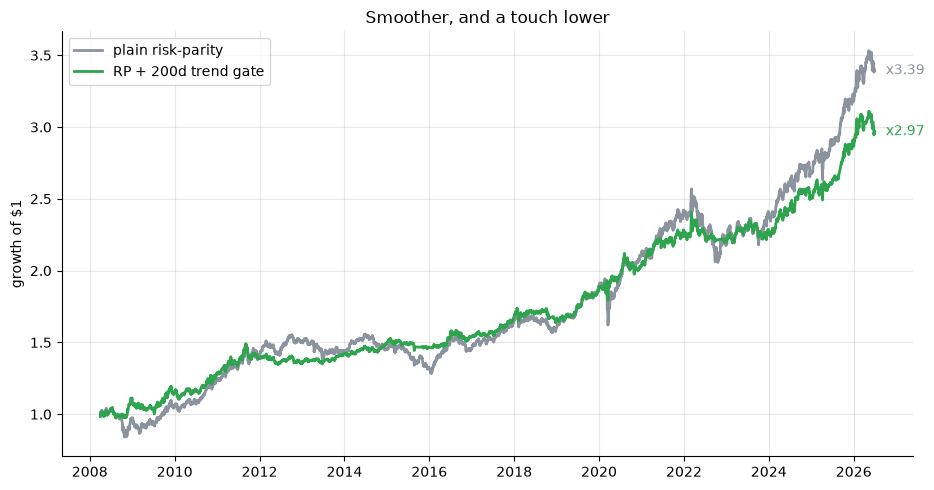

terminal wealth: RP+trend x2.97  vs  plain RP x3.39


In [2]:
if HAVE_REAL:
    nav_p = (1 + RACE['plain_total']).cumprod()
    nav_t = (1 + RACE['trend_total']).cumprod()
    fig, ax = plt.subplots()
    ax.plot(nav_p.index, nav_p, c=GREY, lw=2, label='plain risk-parity')
    ax.plot(nav_t.index, nav_t, c=GREEN, lw=2, label='RP + 200d trend gate')
    for nav, col in ((nav_p, GREY), (nav_t, GREEN)):
        ax.annotate(f'x{nav.iloc[-1]:.2f}', (nav.index[-1], nav.iloc[-1]), color=col,
                    xytext=(8,0), textcoords='offset points', va='center')
    ax.set_ylabel('growth of $1'); ax.set_title('Smoother, and a touch lower')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print(f"terminal wealth: RP+trend x{nav_t.iloc[-1]:.2f}  vs  plain RP x{nav_p.iloc[-1]:.2f}")
else:
    print('cache missing - frozen: RP+trend x%.2f vs plain x%.2f' % (R['t_wealth'], R['p_wealth']))

The green line is calmer and finishes a little lower (**×3.0** vs **×3.4**). Now the two halves of the promise, one at a time.

**Half one: the crashes.** Worst peak-to-trough loss inside each crisis.

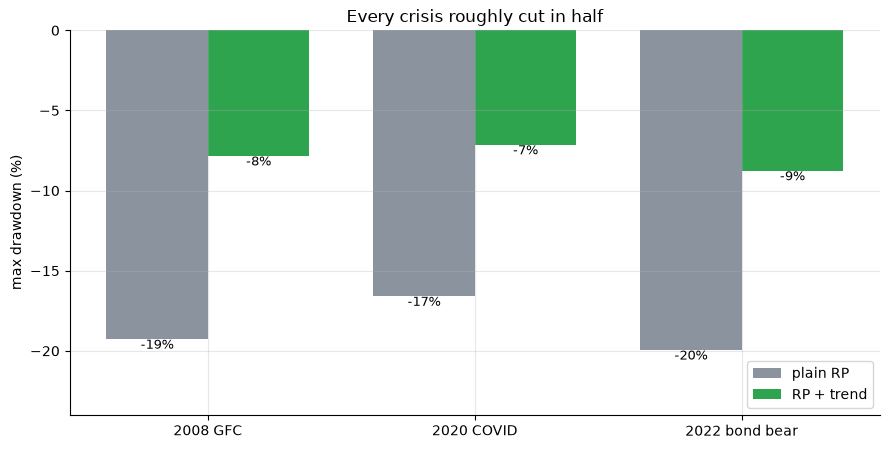

{'2008 GFC': (-7.8, -19.3), '2020 COVID': (-7.1, -16.6), '2022 bond bear': (-8.8, -20.0)}


In [3]:
names = [c[0] for c in R['crises']]
pdd = [c[1] for c in R['crises']]; tdd = [c[2] for c in R['crises']]
if HAVE_REAL:
    wins = {'2008 GFC':('2008-04-01','2009-06-30'), '2020 COVID':('2020-02-01','2020-04-30'),
            '2022 bond bear':('2022-01-01','2022-12-31')}
    names, pdd, tdd = [], [], []
    for nm,(a,b) in wins.items():
        m = (RACE['plain_total'].index>=pd.Timestamp(a)) & (RACE['plain_total'].index<=pd.Timestamp(b))
        names.append(nm); pdd.append(st.max_drawdown(RACE['plain_total'][m])*100)
        tdd.append(st.max_drawdown(RACE['trend_total'][m])*100)
x = np.arange(len(names)); wdt = 0.38
fig, ax = plt.subplots(figsize=(9.0, 4.6))
ax.bar(x - wdt/2, pdd, wdt, color=GREY, label='plain RP')
ax.bar(x + wdt/2, tdd, wdt, color=GREEN, label='RP + trend')
for i,v in enumerate(pdd): ax.annotate(f'{v:.0f}%', (x[i]-wdt/2, v), ha='center', va='top', fontsize=9)
for i,v in enumerate(tdd): ax.annotate(f'{v:.0f}%', (x[i]+wdt/2, v), ha='center', va='top', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('max drawdown (%)'); ax.set_ylim(-24, 0)
ax.set_title('Every crisis roughly cut in half'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()
print(dict(zip(names, zip([round(v,1) for v in tdd], [round(v,1) for v in pdd]))))

Each crash shrinks by about half — **-19% → -8%** in 2008, **-20% → -9%** in the 2022 bond bear (the gate stepped out of Treasuries as they fell below trend). And the quants notebook shows this is *timing*, not just holding less: 200 shuffled gates (same time out of the market, no information) average a **-17%** drawdown — **0 of 200** match the real one. The shield earns its badge.

**Half two: is it a better deal per unit of risk?** Here's the calendar, year by year.

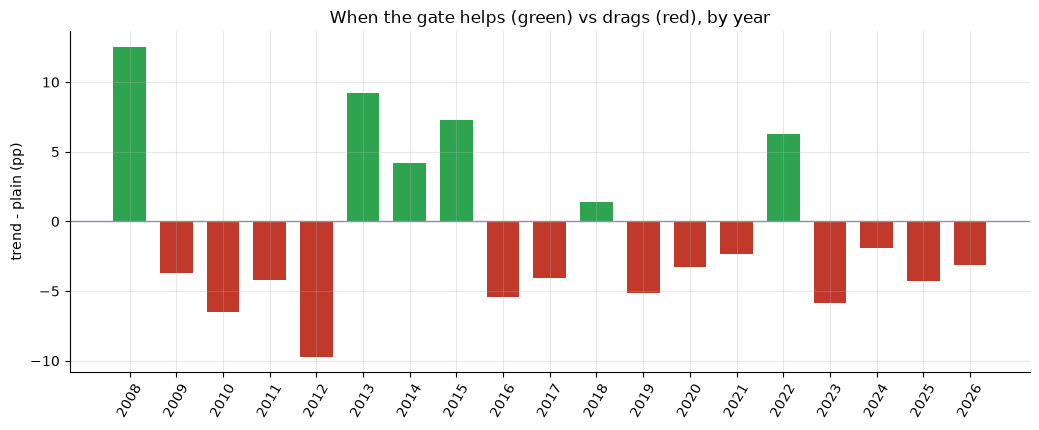

gate added return in 6/19 years; biggest wins are the crisis years


In [4]:
rows = R['cal']
if HAVE_REAL:
    cy = st.calendar_years(RACE)
    rows = [(int(y), cy.loc[y,'plain_%'], cy.loc[y,'trend_%']) for y in cy.index]
yrs = [r[0] for r in rows]; gaps = [r[2]-r[1] for r in rows]
cols = [GREEN if g>=0 else RED for g in gaps]
fig, ax = plt.subplots(figsize=(10.5, 4.4))
ax.bar([str(y) for y in yrs], gaps, color=cols, width=.7)
ax.axhline(0, c=GREY, lw=1)
ax.set_ylabel('trend - plain (pp)'); ax.tick_params(axis='x', rotation=60)
ax.set_title('When the gate helps (green) vs drags (red), by year')
plt.tight_layout(); plt.show()
wins = sum(1 for g in gaps if g>0)
print(f'gate added return in {wins}/{len(gaps)} years; biggest wins are the crisis years')

The pattern is the whole story: the gate **wins big in the crisis years** (2008 **+12.5 pp**, 2015 **+7.3 pp**, 2022 **+6.3 pp**) and **loses small in the calm bull years** (2010, 2012, 2019, 2023 each give back 5–10 pp of cash drag and whipsaw). Add it all up and the Sharpe barely moves (+0.077, statistically indistinguishable from zero) — you paid for the crisis insurance with bull-market premiums.

> 🔬 **For the quants:** the Sharpe edge's 95% confidence interval is **[-0.25, +0.39]** (straddles zero) and it flips sign between the two eras. The drawdown relief, by contrast, is certified as timing (shuffle p = 0.000). Different grades for different halves.

## 5 · The verdict

- **Signal — Mixed.** *Real on the drawdown* (halved, robust across eras and crises, certified as timing by the shuffle test), *weak on the Sharpe* (the risk-adjusted edge never clears significance, +0.077 with a CI through zero, and it flips sign era to era).
- **Tradability — Fragile.** Cheap to run (low turnover, penny-spread ETFs, no shorts) and it survives realistic costs — but what survives scrutiny is **risk control, not extra return**, and it cost a little growth on this one 18-year tape.
- **In one line:** a genuine *shield*, not a certified *edge*.

## 6 · Going further 🚪

- **The gate is honest about what it is** — a *risk* dial. If a −20% risk-parity drawdown is the difference between you holding and you capitulating, paying a little growth to halve it can be rational. Just buy it with open eyes.
- **Why doesn't the Sharpe pop?** Because the 200-day gate is *slow* — it catches the long grinds (2008, 2022) but whipsaws in choppy ranges and always parks in cash a beat late. The crashes it prevents and the premiums it misses roughly cancel.
- **Siblings on this desk.** [68-all-weather](../../68-all-weather/README.md) is the plain risk-parity book this study gates; [110-faber-timing](../../110-faber-timing/README.md) is the same 200-day rule on a single asset; [894-trend-6040](../../894-trend-6040/README.md) puts trend on a 60/40 instead of a risk-parity budget.

*Think a faster gate, or gating the whole book instead of sleeve-by-sleeve, would turn the shield into an edge? Show us a version whose Sharpe advantage clears zero in both eras and we'll re-grade.*